Every month, auto loan securitization trusts are required to file loan-level data
with the SEC under Form ABS-EE. Balance, origination date, days past due,
payment status — for every individual loan in the pool.

The filings are public. The data goes back to 2016. Almost nobody looks at it directly.

The data lake behind this site has ingested all of it: **~9.5 million loans** reported
in a single month at peak, spanning hundreds of trusts and eight-plus years of consumer
credit history. This note is a first look at what that dataset shows.

In [1]:
import os
import hashlib
import urllib.request
import tempfile
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Style ─────────────────────────────────────────────────────────────────────
BLUE   = "#4A6FA5"
AMBER  = "#C8964A"
RED    = "#C86A50"
TEAL   = "#5A8A8A"
MBLUE  = "#7BA3C8"
GREY   = "#D4CFC4"
BG     = "#FAF9F5"
TEXT   = "#1C1C1E"
MUTED  = "#8A8A8A"
FICO_PALETTE = [RED, AMBER, "#C8B86A", "#7EA870", TEAL, BLUE]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.edgecolor":   GREY,
    "axes.labelcolor":  MUTED,
    "axes.titlecolor":  TEXT,
    "axes.grid":        True,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "grid.color":       GREY,
    "grid.linewidth":   0.6,
    "grid.alpha":       0.6,
    "xtick.color":      MUTED,
    "ytick.color":      MUTED,
    "text.color":       TEXT,
    "font.size":        11,
})

# ── Data access ───────────────────────────────────────────────────────────────
R2_BASE = os.environ.get(
    "R2_BASE_URL",
    "https://bens-field-notes-r2.benuehlinger-dev.workers.dev",
).rstrip("/")
UA    = {"User-Agent": "bens-field-notes-notebook/1.0"}
CACHE = Path(tempfile.mkdtemp(prefix="abs-ee-intro-"))

def fetch(key: str) -> Path:
    dest = CACHE / (hashlib.md5(key.encode()).hexdigest() + ".parquet")
    if dest.exists() and dest.stat().st_size > 0:
        return dest
    req = urllib.request.Request(f"{R2_BASE}/{key}", headers=UA)
    with urllib.request.urlopen(req, timeout=180) as r, open(dest, "wb") as f:
        f.write(r.read())
    return dest

con = duckdb.connect()

def catalog(yyyymm: str) -> pd.DataFrame:
    d = fetch(f"abs_ee/curated/catalog/{yyyymm}_autoloan.parquet")
    return con.execute(f"SELECT * FROM read_parquet('{d}') WHERE status='ok'").fetchdf()

def loan_files(yyyymm: str, max_files: int = 6) -> list[str]:
    cat = catalog(yyyymm)
    singles = (
        cat[~cat["r2_keys"].str.contains("|", regex=False)]
        .nlargest(max_files, "loan_count")
    )
    paths = []
    for key in singles["r2_keys"]:
        try:
            paths.append(str(fetch(key)))
        except Exception:
            pass
    return paths

def sql_files(paths: list[str]) -> str:
    return "[" + ", ".join(f"'{p}'" for p in paths) + "]"


## How fast did the panel grow?

Regulation AB II filing requirements have expanded over the years, and issuers
have grown their trust programs. The result: the number of loans reportable in
a single month grew more than **30x** between early 2017 and mid-2023.

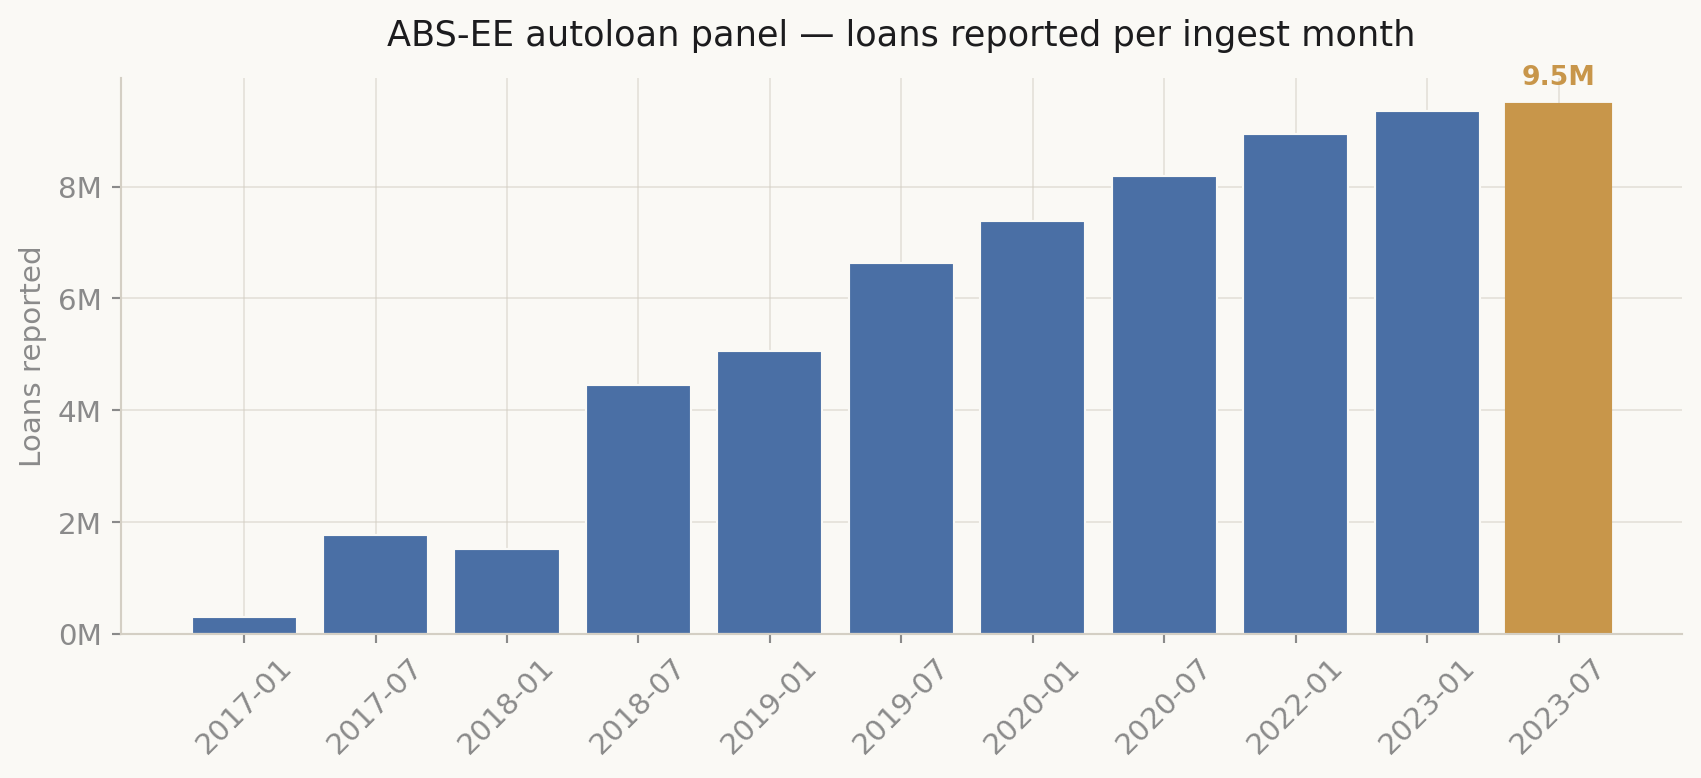

In [2]:
CATALOG_MONTHS = [
    "201701", "201707", "201801", "201807",
    "201901", "201907", "202001", "202007",
    "202201", "202301", "202307",
]

volume_rows = []
for m in CATALOG_MONTHS:
    try:
        d = fetch(f"abs_ee/curated/catalog/{m}_autoloan.parquet")
        r = con.execute(
            f"SELECT COUNT(*) filings, SUM(loan_count) loans "
            f"FROM read_parquet('{d}') WHERE status='ok'"
        ).fetchone()
        if r[1]:
            volume_rows.append({"label": f"{m[:4]}-{m[4:]}", "filings": int(r[0]), "loans": int(r[1])})
    except Exception:
        pass

vol = pd.DataFrame(volume_rows)

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.bar(vol["label"], vol["loans"] / 1e6, color=BLUE, edgecolor=BG, linewidth=0.8)

# Annotate peak
peak_idx = vol["loans"].idxmax()
bars[peak_idx].set_color(AMBER)
ax.annotate(
    f"{vol.loc[peak_idx,'loans']/1e6:.1f}M",
    xy=(peak_idx, vol.loc[peak_idx, "loans"] / 1e6),
    xytext=(peak_idx, vol.loc[peak_idx, "loans"] / 1e6 + 0.35),
    ha="center", fontsize=10, color=AMBER, fontweight="bold",
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))
ax.set_ylabel("Loans reported")
ax.set_title("ABS-EE autoloan panel — loans reported per ingest month", pad=12)
ax.tick_params(axis="x", rotation=45)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

The plateau around 9 million loans in 2022–2023 represents something close to the full
Reg AB II ABS filing universe — the issuers who are required to file are mostly filing.

The early ramp is partly regulatory (more issuers came into scope over time) and partly
growth in the underlying securitization market.

---

## Who is getting these loans?

The ABS-EE universe skews toward the securitized segment of auto credit — which means
larger banks, captive finance arms, and specialty lenders. It is not a random sample
of all auto borrowers. But within that universe, credit quality spans a wide range.

Below: FICO distribution for a sample of the six largest single-file trusts from
**July 2018** and **July 2023**, side by side.

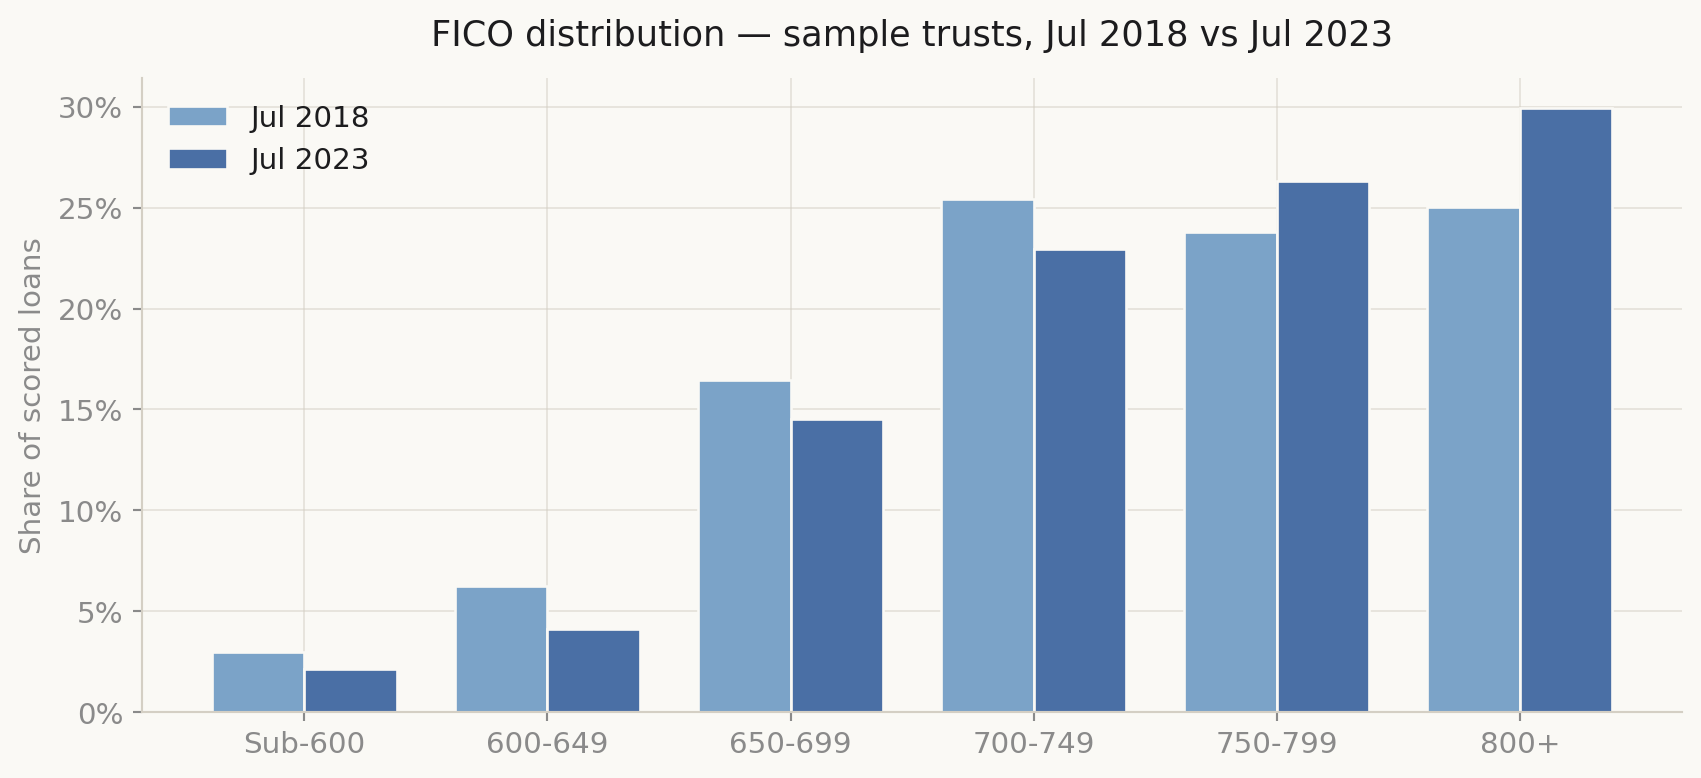

In [3]:
paths_2018 = loan_files("201807", 6)
paths_2023 = loan_files("202307", 6)

FICO_BUCKETS = ["Sub-600", "600-649", "650-699", "700-749", "750-799", "800+"]

def fico_distribution(paths: list[str]) -> pd.DataFrame:
    f = sql_files(paths)
    return con.execute(f"""
        SELECT
            CASE WHEN s<600 THEN 'Sub-600' WHEN s<650 THEN '600-649'
                 WHEN s<700 THEN '650-699' WHEN s<750 THEN '700-749'
                 WHEN s<800 THEN '750-799' ELSE '800+' END AS bucket,
            COUNT(*) AS n, MIN(s) AS sort_key
        FROM (SELECT TRY_CAST(obligorCreditScore AS DOUBLE) AS s
              FROM read_parquet({f}, union_by_name=true))
        WHERE s BETWEEN 300 AND 850
        GROUP BY 1 ORDER BY sort_key
    """).fetchdf()

fd18 = fico_distribution(paths_2018)
fd23 = fico_distribution(paths_2023)

# Normalise to share
fd18["share"] = fd18["n"] / fd18["n"].sum() * 100
fd23["share"] = fd23["n"] / fd23["n"].sum() * 100

x   = range(len(FICO_BUCKETS))
w   = 0.38

fig, ax = plt.subplots(figsize=(9, 4.2))
b1 = ax.bar([i - w/2 for i in x], fd18["share"], w, label="Jul 2018", color=MBLUE, edgecolor=BG)
b2 = ax.bar([i + w/2 for i in x], fd23["share"], w, label="Jul 2023", color=BLUE, edgecolor=BG)

ax.set_xticks(list(x))
ax.set_xticklabels(FICO_BUCKETS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_ylabel("Share of scored loans")
ax.set_title("FICO distribution — sample trusts, Jul 2018 vs Jul 2023", pad=12)
ax.legend(frameon=False)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

The 800+ bucket grew meaningfully between 2018 and 2023 in this sample,
while the sub-650 buckets shrank. Some of that is compositional — which trusts are
in the sample — but it is consistent with the broader narrative that lenders
tightened standards through the post-COVID period.

---

## How have loan terms changed?

Loan size and term are where the most notable shifts show up. Average original balances
increased sharply — partly vehicle price inflation, partly a structural move toward
longer-term financing.

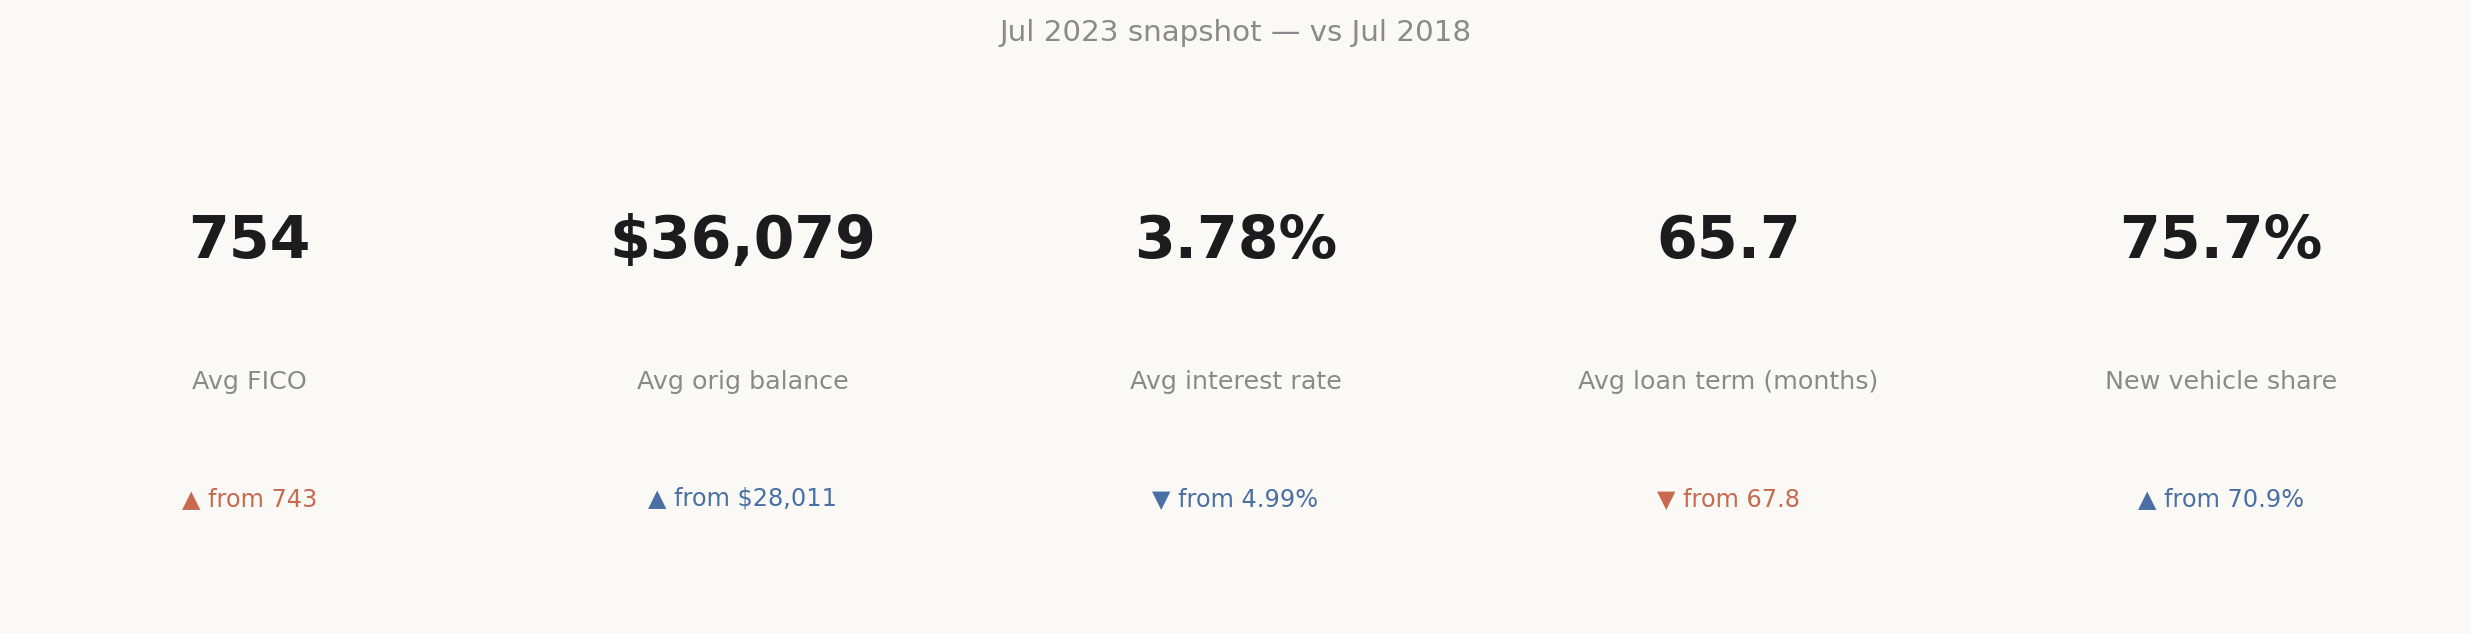

In [4]:
def loan_characteristics(paths: list[str], label: str) -> dict:
    f = sql_files(paths)
    r = con.execute(f"""
        SELECT
            '{label}' AS period,
            COUNT(*) AS loans,
            ROUND(AVG(TRY_CAST(obligorCreditScore AS DOUBLE)), 0) AS avg_fico,
            ROUND(AVG(CASE WHEN originalInterestRatePercentage > 0
                THEN originalInterestRatePercentage END) * 100, 2) AS avg_rate_pct,
            ROUND(AVG(originalLoanTerm), 1) AS avg_term_mo,
            ROUND(AVG(originalLoanAmount), 0) AS avg_orig_bal,
            ROUND(100.0 * SUM(CASE WHEN vehicleNewUsedCode = 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_new_vehicle
        FROM read_parquet({f}, union_by_name=true)
        WHERE TRY_CAST(obligorCreditScore AS DOUBLE) BETWEEN 300 AND 850
    """).fetchdf()
    return r.iloc[0].to_dict()

c18 = loan_characteristics(paths_2018, "Jul 2018")
c23 = loan_characteristics(paths_2023, "Jul 2023")

metrics = [
    ("Avg FICO",              c18["avg_fico"],       c23["avg_fico"],       "{:.0f}",  False),
    ("Avg orig balance",      c18["avg_orig_bal"],    c23["avg_orig_bal"],    "${:,.0f}", True),
    ("Avg interest rate",     c18["avg_rate_pct"],    c23["avg_rate_pct"],    "{:.2f}%", False),
    ("Avg loan term (months)",c18["avg_term_mo"],     c23["avg_term_mo"],     "{:.1f}",  True),
    ("New vehicle share",     c18["pct_new_vehicle"], c23["pct_new_vehicle"], "{:.1f}%", True),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(13, 3.2))
fig.patch.set_facecolor(BG)

for ax, (label, v18, v23, fmt, higher_is_pos) in zip(axes, metrics):
    ax.set_facecolor(BG)
    ax.axis("off")
    change = v23 - v18
    arrow  = "▲" if change > 0 else "▼"
    color  = BLUE if (change > 0) == higher_is_pos else RED
    ax.text(0.5, 0.82, fmt.format(v23), ha="center", va="top",
            fontsize=22, fontweight="bold", color=TEXT, transform=ax.transAxes)
    ax.text(0.5, 0.50, label, ha="center", va="top",
            fontsize=9.5, color=MUTED, transform=ax.transAxes)
    ax.text(0.5, 0.26, f"{arrow} from {fmt.format(v18)}", ha="center", va="top",
            fontsize=9, color=color, transform=ax.transAxes)

fig.suptitle("Jul 2023 snapshot — vs Jul 2018", y=1.02, fontsize=11, color=MUTED)
fig.tight_layout()
plt.show()

The numbers tell a consistent story:

- **Loan sizes up 29%** — from $28K to $36K average original balance. Vehicle prices drove this; the same car costs more.
- **Rates down** — 5.0% to 3.8% reflects where we were in the rate cycle in mid-2023 relative to 2018 for this credit quality sample.
- **Terms already long** — 68 months average in 2018, still 66 months in 2023. 5-6 year auto loans have been standard for a while.
- **FICO up** — 743 to 754 in this sample. Partly compositional, partly real tightening.

---

## Who is behind on payments?

Delinquency is reported as of the servicer's reporting period end date.
Status code 0 means current; higher codes indicate successive payment periods behind.
A substantial number of loans have no status reported at all — those are excluded here.

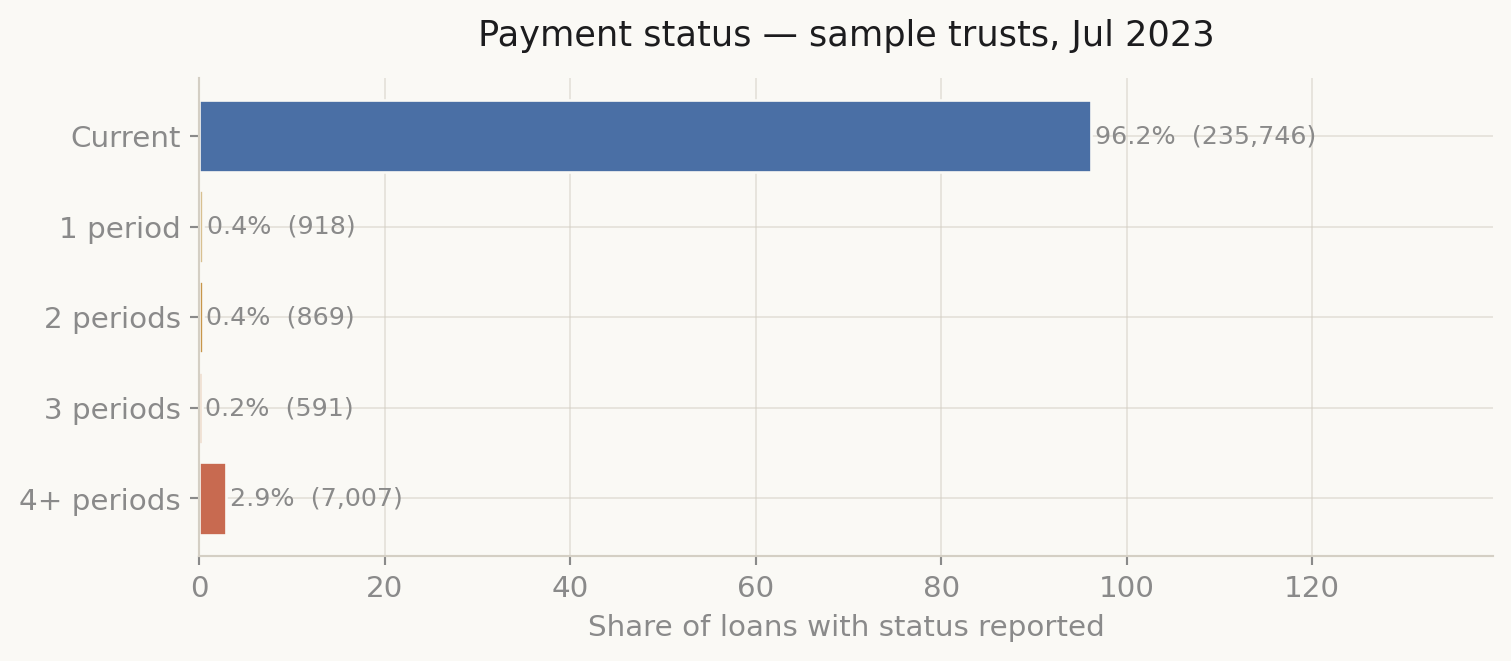

In [5]:
f23 = sql_files(paths_2023)

delinq = con.execute(f"""
    SELECT
        CASE
            WHEN LOWER(CAST(currentDelinquencyStatus AS VARCHAR)) IN ('current','0')
                THEN 'Current'
            WHEN TRY_CAST(currentDelinquencyStatus AS INTEGER) = 1 THEN '1 period'
            WHEN TRY_CAST(currentDelinquencyStatus AS INTEGER) = 2 THEN '2 periods'
            WHEN TRY_CAST(currentDelinquencyStatus AS INTEGER) = 3 THEN '3 periods'
            ELSE '4+ periods'
        END AS bucket,
        COUNT(*) AS n,
        MIN(TRY_CAST(currentDelinquencyStatus AS INTEGER)) AS sort_key
    FROM read_parquet({f23}, union_by_name=true)
    WHERE currentDelinquencyStatus IS NOT NULL
    GROUP BY 1 ORDER BY sort_key
""").fetchdf()

delinq["share"] = delinq["n"] / delinq["n"].sum() * 100
DELINQ_COLORS = {"Current": BLUE, "1 period": "#D8C090", "2 periods": AMBER,
                 "3 periods": "#C87840", "4+ periods": RED}

fig, ax = plt.subplots(figsize=(8, 3.6))
colors = [DELINQ_COLORS.get(b, GREY) for b in delinq["bucket"]]
bars   = ax.barh(delinq["bucket"], delinq["share"], color=colors, edgecolor=BG)

for bar, row in zip(bars, delinq.itertuples()):
    ax.text(
        bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
        f"{row.share:.1f}%  ({row.n:,})",
        va="center", fontsize=9.5, color=MUTED,
    )

ax.set_xlabel("Share of loans with status reported")
ax.set_title("Payment status — sample trusts, Jul 2023", pad=12)
ax.set_xlim(0, delinq["share"].max() * 1.45)
ax.invert_yaxis()
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

In this sample — six large trusts from the July 2023 reporting period — roughly **94% of loans
with reported status were current**. The 4+ period bucket (borrowers four or more payment
cycles behind) accounts for the bulk of delinquency; borrowers tend to roll forward
quickly or fall further behind, with relatively few staying in the 1-3 period range.

One important caveat: this sample overrepresents prime trusts because it selects the
largest single-file trusts by loan count. Subprime trusts tend to split into multiple
Parquet files. The full panel delinquency picture — across all 210+ trusts — is on the
[live dashboard](../../dashboards/abs-ee.qmd).

---

## The data

Everything in this notebook was fetched at render time from a private Cloudflare R2
bucket containing Parquet files processed from raw SEC EDGAR ABS-EE XML filings.
The full pipeline is at
[github.com/benuehlinger/bens-data-lake](https://github.com/benuehlinger/bens-data-lake).
Field definitions are on the [Data Sources](../../data-sources.qmd) page.

Code for this notebook is visible — click **< > Code** in the top right to expand all
source cells.